In [200]:
# !pip install skorch

In [289]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

import torch
import torch.nn as nn

from torch.utils.data import TensorDataset, DataLoader
import torch.optim as optim

from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

from skorch import NeuralNetClassifier

In [290]:
df = pd.read_csv("data/DateFruit_Dataset.csv")

>Null value doesn't exists in dataset

In [291]:
df.shape

(898, 35)

In [292]:
df["Class"].value_counts()

Class
DOKOL     204
SAFAVI    199
ROTANA    166
DEGLET     98
SOGAY      94
IRAQI      72
BERHI      65
Name: count, dtype: int64

> type of class: 7  => 7 output neurons

And We have to predict them.

### Split data

In [293]:
# Data split
X = df.drop("Class", axis=1)
y = df["Class"]

# encode the label 
le = LabelEncoder()
y = le.fit_transform(y)

# split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train = X_train.astype('float32')
X_test = X_test.astype('float32')

### Define FNN Model 

In [294]:
# Define ANN Model for classification
class FNN(nn.Module):
    def __init__(self, num_inputs):
        super(FNN, self).__init__()

        self.model = nn.Sequential(
            # Input layer -> auto define by 1st hidden layer
            
            # 1st layer
            nn.Linear(num_inputs, 64), # Input, output=64 
            nn.ReLU(),

            # 2nd layer
            nn.Linear(64, 64), # Input=64, output=64
            nn.ReLU(),

            # output layer
            # we use: Softmax AF (for: 5 classes -> 5 output neurons)
            nn.Linear(64, 7) # it give us Logits => raw scores [not probailities]
            # SoftMax by default apply by CrossEntropyLoss
        )
    
    def forward(self, x):
        return self.model(x)

### Wrap the Module with **Skorch**

In [295]:
# Skorch handles tensor conversion
estimator = NeuralNetClassifier(
    module = FNN,
    # module__num_inputs=32, This passes 32 to __init__(num_inputs)
    criterion = nn.CrossEntropyLoss,
    optimizer = optim.Adam,
    max_epochs=100,
    lr=0.01,
)

## Build Pipeline

In [296]:
pipe = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components="mle")),
        ("nn", estimator),
    ]
)

In [297]:
# Extract the exact shape PCA outputs
X_scalled_pca = pipe['pca'].fit_transform(
    pipe['scaler'].fit_transform(X_train)
)
num_pca_features = X_scalled_pca.shape[1]
print("Num PCA Features: ", num_pca_features)

Num PCA Features:  32


## Fit

In [298]:
pipe.set_params(nn__module__num_inputs=num_pca_features)
pipe.fit(X_train, y_train.astype('int64'))

  epoch    train_loss    valid_acc    valid_loss     dur
-------  ------------  -----------  ------------  ------
      1        1.7183       0.6181        1.1901  0.0242
      2        0.9414       0.7083        0.7172  0.0293
      3        0.5538       0.8264        0.4387  0.0281
      4        0.3548       0.8889        0.3163  0.0235
      5        0.2505       0.9097        0.2581  0.0248
      6        0.2003       0.9097        0.2636  0.0235
      7        0.1626       0.9167        0.2400  0.0302
      8        0.1421       0.9236        0.2482  0.0435
      9        0.1209       0.9306        0.2321  0.0309
     10        0.1076       0.9236        0.2392  0.0312
     11        0.0937       0.9306        0.2292  0.0334
     12        0.0837       0.9236        0.2467  0.0310
     13        0.0731       0.9236        0.2628  0.0217
     14        0.0654       0.9236        0.2685  0.0415
     15        0.0584       0.9236        0.2871  0.0279
     16        0.0517       0.9

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('pca', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",'mle'
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto',

## Validation

In [299]:
from sklearn.metrics import accuracy_score, classification_report

# generate pred from pipeline
y_pred = pipe.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Final Test Accuracy: {accuracy * 100:.2f}% \n")

print("Classification Report:")
print(classification_report(y_test, y_pred))

Final Test Accuracy: 91.67% 

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.83      0.91        12
           1       0.77      0.85      0.81        20
           2       1.00      0.94      0.97        50
           3       0.67      1.00      0.80        10
           4       1.00      0.86      0.92        35
           5       1.00      1.00      1.00        33
           6       0.78      0.90      0.84        20

    accuracy                           0.92       180
   macro avg       0.89      0.91      0.89       180
weighted avg       0.93      0.92      0.92       180



## Plot the loss curve visually

During training, **skorch** automatically **logs** the training loss (**train_loss**), validation loss (**valid_loss**), and validation accuracy (**valid_acc**) for every single epoch.

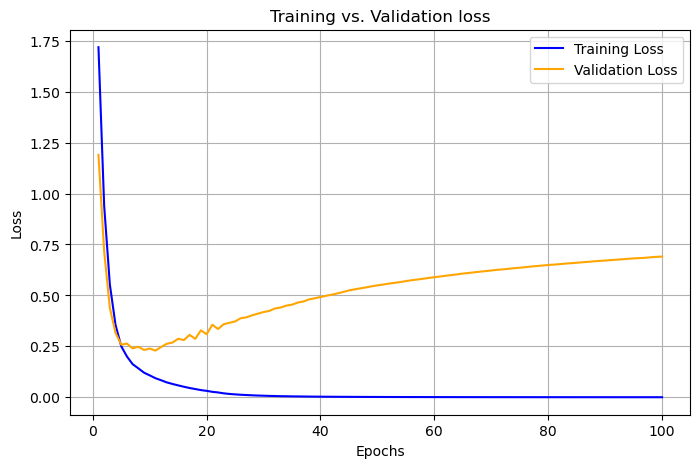

In [300]:
import matplotlib.pyplot as plt

history = pipe['nn'].history

epochs =history[:, "epoch"]
train_losses = history[:, "train_loss"]
valid_losses = history[:, "valid_loss"]

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_losses, label="Training Loss", color="blue")
plt.plot(epochs, valid_losses, label="Validation Loss", color="orange")

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs. Validation loss")
plt.legend()
plt.grid(True)

### Current Model is in Overfitting Condition
Because for **healthy model**:
- both line steadily decrease together and flatten out at a low value.

BUt here **Overfitting Model**:
- training loss: continues drop toward zero
- validation loss: after hit a minimum point and then **start to climbing upward**
- that means our model is **memorising the training data**
- and model lossing its ability to generalise

# Overfitting Condition Fix

we use three effective ways:

1. Adding **Dropout layers**
2. Adding **weight Decay** (L2 regularixation)
3. Implementing **Early Stopping**

## 1. Add Dropout layers

This randomly shuts down neurons during training, forcing the network to **learn robust patterns** instead of memorizing the data.

#### Why this stops overfitting
- **No over-reliance**:  It prevents **overfitting** by stopping the network from relying too much on specific neurons.
- **Forces Teamwork**: Because neurons keep turning off, every single neuron is forced to learn useful patterns independently.
- It creates a much more stable model that performs better on unseen test data

**Notes:** It only runs durring **training**. It turns off automatically during **testing/evaluation**.
> if call **.predict()** than Dropout automatically turns off (0% drops)

In [311]:
# Define FNN Model for classification
class RobustFNN(nn.Module):
    def __init__(self, num_inputs):
        super(RobustFNN, self).__init__()

        self.model = nn.Sequential(
            # Input layer -> auto define by 1st hidden layer
            
            # 1st layer
            nn.Linear(num_inputs, 64), # Input, output=64 
            nn.ReLU(),
            nn.Dropout(p=0.5), # Randomly drop 50% of activations

            # 2nd layer
            nn.Linear(64, 64), # Input=64, output=64
            nn.ReLU(),
            nn.Dropout(p=0.3), # Drop 30% of activations 

            # output layer
            # we use: Softmax AF (for: 5 classes -> 5 output neurons)
            nn.Linear(64, 7) # it give us Logits => raw scores [not probailities]
            # SoftMax by default apply by CrossEntropyLoss
        )
    
    def forward(self, x):
        return self.model(x)

## 2. Add Weight Decay & Early Stopping

#### L2 Regularization
- Add a **penalty** to the model's loss function based on the size of weights
- it prevents **overfitting** by stopping the weights from becoming too large
- forces the NN to keep its weights as small and close to zero as possible.

In [312]:
from skorch.callbacks import EarlyStopping

estimator = NeuralNetClassifier(
    module=RobustFNN, # Use new Architecture with dropout
    criterion=nn.CrossEntropyLoss,
    optimizer=optim.Adam,
    max_epochs=100,
    lr=0.001, # Lower learning rate for a smoother convergence

    # FIx: Penalize complex weights (l2 Regularixation)
    optimizer__weight_decay=1e-4, # 1e-4 = 0.0001 

    callbacks=[
        EarlyStopping(
            monitor='valid_loss',
            patience=5,
            lower_is_better=True
    )],
)

In [313]:
# Rebuild pipeline with updated steps
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components="mle")),
    ('nn', estimator)
])

# Dynamically set features
X_scaled_pca = pipe['pca'].fit_transform(pipe['scaler'].fit_transform(X_train))
pipe.set_params(nn__module__num_inputs=X_scaled_pca.shape[1])

# Fit with regularization active
pipe.fit(X_train, y_train.astype('int64'))

  epoch    train_loss    valid_acc    valid_loss     dur
-------  ------------  -----------  ------------  ------
      1        1.9494       0.2361        1.8741  0.0395
      2        1.8546       0.3819        1.7790  0.0325
      3        1.7545       0.5417        1.6826  0.0256
      4        1.6883       0.5694        1.5823  0.0348
      5        1.5870       0.5903        1.4765  0.0344
      6        1.4713       0.5903        1.3677  0.0334
      7        1.3634       0.5972        1.2594  0.0376
      8        1.2728       0.6111        1.1570  0.0232
      9        1.1684       0.6181        1.0637  0.0347
     10        1.0942       0.6250        0.9825  0.0326
     11        1.0116       0.6389        0.9139  0.0290
     12        0.9509       0.6667        0.8550  0.0341
     13        0.8795       0.6875        0.8034  0.0290
     14        0.8386       0.6875        0.7560  0.0372
     15        0.7808       0.7222        0.7123  0.0330
     16        0.7541       0.7

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('pca', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",'mle'
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto',

In [315]:
y_pred = pipe.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Final Test Accuracy: {accuracy * 100:.2f}% \n")

print("Classification Report:")
print(classification_report(y_test, y_pred))

Final Test Accuracy: 93.33% 

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.92      0.92        12
           1       0.80      0.80      0.80        20
           2       0.96      0.98      0.97        50
           3       0.82      0.90      0.86        10
           4       1.00      0.94      0.97        35
           5       1.00      1.00      1.00        33
           6       0.85      0.85      0.85        20

    accuracy                           0.93       180
   macro avg       0.91      0.91      0.91       180
weighted avg       0.93      0.93      0.93       180



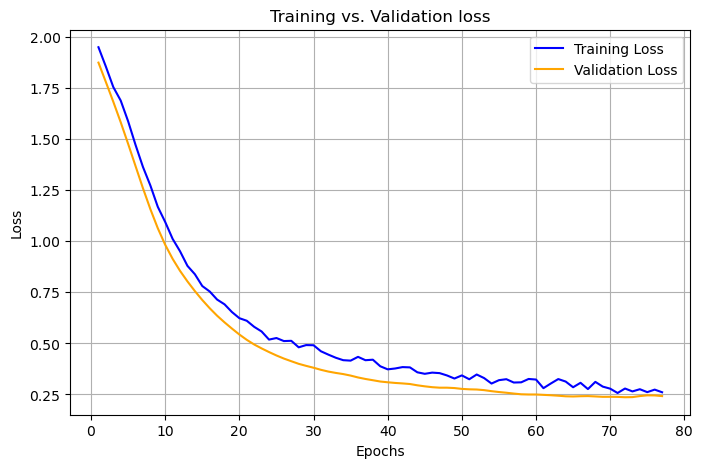

In [316]:
# Plot the loss curve visually

import matplotlib.pyplot as plt

history = pipe['nn'].history

epochs =history[:, "epoch"]
train_losses = history[:, "train_loss"]
valid_losses = history[:, "valid_loss"]

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_losses, label="Training Loss", color="blue")
plt.plot(epochs, valid_losses, label="Validation Loss", color="orange")

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs. Validation loss")
plt.legend()
plt.grid(True)